# 01 — Detections QA: ESP_069669_2220

Stage 0–1 walking skeleton. Loads the manifest + config, resolves the target CTX CRS
(hardcoded canonical IAU 2000 Mars equirectangular per `DECISIONS.md`), reprojects the
ESP_069669_2220 BoulderNet detections, and plots the polygon footprint with the manifest
center overlay + the measured centroid residual annotated.

Imports from `src/`; computation happens in the modules — this notebook is for inspection.

**Why ESP_069669_2220?** 4 of the 10 manifest images have BoulderNet outputs with
geometry mis-located by hundreds of km from the manifest center. ESP_069669_2220 is
verified-good (residual ~6 km on 2026-05-20). See `02_investigate_misplaced_detections.ipynb`
for a look at the bad cases.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from pyproj import CRS, Transformer

from src import detections, manifest as M, qa
from src.config import load_config, REPO_ROOT
from src.ctx_retrieve import resolve_target_crs

OBS_ID = "ESP_069669_2220"
FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config("config.yaml")
df = M.load_manifest(cfg.manifest_path)
row = df.set_index("ObsId").loc[OBS_ID]
print(f"manifest center: lat={row['CenterLat']:.4f}, lon_180={row['CenterLon_180']:.4f}, tile={row['CTX_TileName']}")

manifest center: lat=41.6915, lon_180=0.8290, tile=E000_N40


In [2]:
target_wkt = resolve_target_crs(cfg)
target_crs = CRS.from_user_input(target_wkt)
print(f"target CRS name: {target_crs.name}")
print(f"sphere radius:   {target_crs.ellipsoid.semi_major_metre:.3f} m")
print(f"central meridian: {target_crs.coordinate_operation.params[1].value:.1f}° (Longitude of natural origin)")
print(f"config hash:      {cfg.hash[:12]}")

target CRS name: Mars_2000_Equidistant_Cylindrical
sphere radius:   3396190.000 m
central meridian: 0.0° (Longitude of natural origin)
config hash:      e27f940c1986


In [3]:
gdf_t, gpkg, correction = detections.stage1_one_image(
    OBS_ID,
    detections_root=cfg.detections_root,
    target_crs=target_wkt,
    cache_dir=cfg.cache_dir,
    config_hash=cfg.hash,
    manifest_row=row,
)
print(f"reprojected polygons: {len(gdf_t)}  (cache: {gpkg})")
print(f"correction: {correction}")
result = qa.assert_centroid_consistent(
    gdf_t,
    obs_id=OBS_ID,
    manifest_lat_deg=float(row['CenterLat']),
    manifest_lon_deg=float(row['CenterLon_180']),
    max_km=float(cfg['sanity']['centroid_max_km']),
)
print(f"centroid residual: {result.distance_m:.1f} m  (threshold {result.threshold_m:.0f} m)")

reprojected polygons: 1462  (cache: C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\cache\reprojected_detections\ESP_069669_2220.gpkg)
correction: {'status': 'trusted_prj'}
centroid residual: 6256.9 m  (threshold 15000 m)


figure saved: C:\Users\brian\Documents\PhD\HiRiseToCTXBoulders\hirise2ctx\reports\figures\01_detections_ESP_069669_2220.png


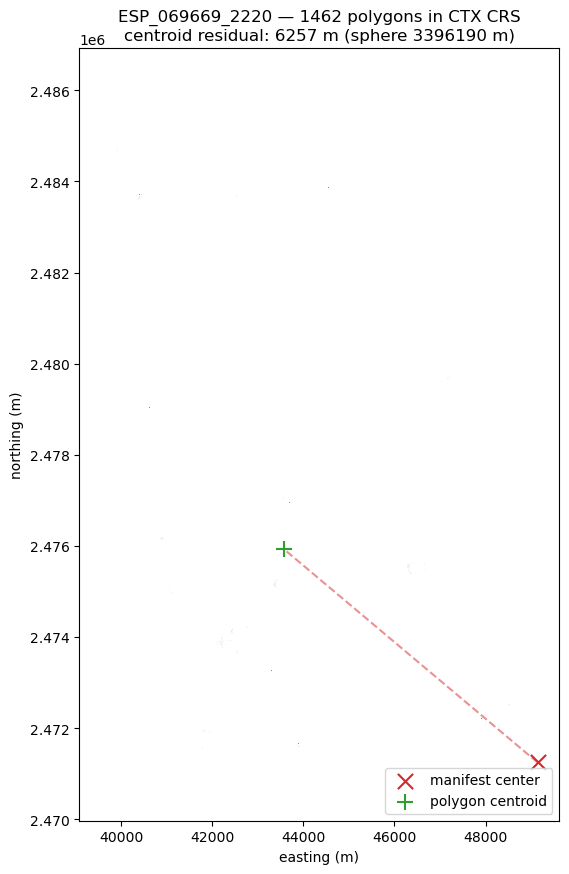

In [4]:
to_target = Transformer.from_crs(target_crs.geodetic_crs, target_crs, always_xy=True)
manifest_x, manifest_y = to_target.transform(row['CenterLon_180'], row['CenterLat'])
union = gdf_t.geometry.union_all()
cx, cy = union.centroid.x, union.centroid.y

fig, ax = plt.subplots(figsize=(7, 9))
gdf_t.plot(ax=ax, color='#1f77b4', edgecolor='none', alpha=0.7)
ax.scatter([manifest_x], [manifest_y], marker='x', s=120, color='#d62728', label='manifest center', zorder=5)
ax.scatter([cx], [cy], marker='+', s=140, color='#2ca02c', label='polygon centroid', zorder=5)
ax.plot([manifest_x, cx], [manifest_y, cy], color='#d62728', linestyle='--', alpha=0.5)
ax.set_xlabel('easting (m)')
ax.set_ylabel('northing (m)')
ax.set_title(f"{OBS_ID} — {len(gdf_t)} polygons in CTX CRS\n"
             f"centroid residual: {result.distance_m:.0f} m (sphere {result.target_sphere_m:.0f} m)")
ax.set_aspect('equal')
ax.legend(loc='lower right')
fig.tight_layout()
out_path = FIG_DIR / f"01_detections_{OBS_ID}.png"
fig.savefig(out_path, dpi=150)
print(f"figure saved: {out_path}")